# Heart Disease Dataset - ML Internship

Task 3: Data Preprocessing and model buidling for Machine Learning

Dataset Source: UCI Machine Learning Repository

In [ ]:
# First we import libraries which are necessary to us right now

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('breast-cancer.data', header=None)

In [ ]:
# It shows first 5 rows of the dataset you can pass (10) to see 10

df.head()

,0,1,2,3,4,5,6,7,8,9
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [ ]:
# Naming the columns

df.columns = ('Class', 'age', 'menopause', 'tumor-size', 'inv-nodes', 'node-caps', 'deg-malig', 'breast', 'breast-quad', 'irradiat')

In [ ]:
df.head()

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [ ]:
# Now getting to know the shape of the dataset aka dataset size and features

df.shape

(286, 10)

In [ ]:
# Now info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class        286 non-null    object
 1   age          286 non-null    object
 2   menopause    286 non-null    object
 3   tumor-size   286 non-null    object
 4   inv-nodes    286 non-null    object
 5   node-caps    286 non-null    object
 6   deg-malig    286 non-null    int64 
 7   breast       286 non-null    object
 8   breast-quad  286 non-null    object
 9   irradiat     286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB


In [ ]:
df.isnull().sum()

,0
Class,0
age,0
menopause,0
tumor-size,0
inv-nodes,0
node-caps,0
deg-malig,0
breast,0
breast-quad,0
irradiat,0


In [ ]:
import numpy as np

df.replace('?',np.nan, inplace=True)

In [ ]:
df.isnull().sum()

,0
Class,0
age,0
menopause,0
tumor-size,0
inv-nodes,0
node-caps,8
deg-malig,0
breast,0
breast-quad,1
irradiat,0


In [ ]:
# Filling missing values

df['node-caps']= df['node-caps'].fillna(df['node-caps'].mode()[0])
df['breast-quad']= df['breast-quad'].fillna(df['breast-quad'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Class,0
age,0
menopause,0
tumor-size,0
inv-nodes,0
node-caps,0
deg-malig,0
breast,0
breast-quad,0
irradiat,0


In [ ]:
df = df.drop_duplicates()


In [ ]:
df.shape

(272, 10)

In [ ]:
# Importing labelEncoder from sklearn
from sklearn.preprocessing import LabelEncoder

# Creating labelEncoder object
le = LabelEncoder()

# Looping through all columns and encoding each one
for col in df.columns:
  df[col] = le.fit_transform(df[col])

# Checking the first 5 rows after encoding
df.head()

# Basically converted all text type data -> integer

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,0,1,2,5,0,0,2,0,1,0
1,0,2,2,3,0,0,1,1,4,0
2,0,2,2,3,0,0,1,0,1,0
3,0,4,0,2,0,0,1,1,2,0
4,0,2,2,0,0,0,1,1,3,0


In [42]:
# Now Scaling all the columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop('Class', axis=1)
y = df['Class']

X_scaled = scaler.fit_transform(X)

In [47]:
print(X_scaled[:5])

[[-1.64245602  0.93777568  0.41228311 -0.56871907 -0.50344436  1.28
  -0.94978835 -0.72707905 -0.57168984]
 [-0.65188387  0.93777568 -0.51450206 -0.56871907 -0.50344436 -0.08
   1.05286615  2.01966403 -0.57168984]
 [-0.65188387  0.93777568 -0.51450206 -0.56871907 -0.50344436 -0.08
  -0.94978835 -0.72707905 -0.57168984]
 [ 1.32926041 -1.09469432 -0.97789464 -0.56871907 -0.50344436 -0.08
   1.05286615  0.18850198 -0.57168984]
 [-0.65188387  0.93777568 -1.90467981 -0.56871907 -0.50344436 -0.08
   1.05286615  1.104083   -0.57168984]]


# Applying Train & Test Split

In [48]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train , y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Trainig size:", X_train.shape)
print("Testing size:", X_test.shape)

Trainig size: (217, 9)
Testing size: (55, 9)


# Building the Model

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model Training completed")

Model Training completed


In [51]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [53]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print("Model Accuracy", accuracy*100, "%")

Model Accuracy 72.72727272727273 %


In [56]:
import seaborn as sns

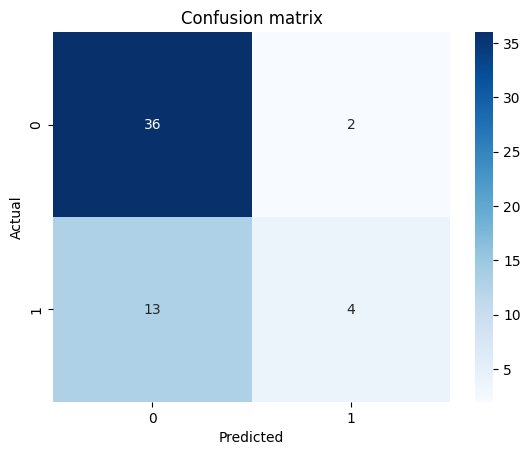

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()